In [1]:
%load_ext autoreload
%autoreload 2

# Part 5: Titanic - Data Preprocessing
Goal of this notebook is solving the messy of Titanic dataset for training:
* **Categorical Data:** Contains text features such as gender ("male","female") or or embarkation ports ("S","C","Q")
* **Missing Values:** Many passengers have missing records regarding their `Age` or `Cabin`
* **Varying Scales:** The `Fare` can range up to hundreds of dollars, while binary features are just 0 or 1. Without scaling, the Gradient Descent optimazation will struggled. 

## Import libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 1. Load dataset

In [10]:
train_df=pd.read_csv('../data/raw/train.csv',header=0)
test_df=pd.read_csv('../data/raw/test.csv',header=0)

In [4]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Check shape, columns, non-null data**

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Check number of missing values each columns**

In [18]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 2. Exploratory Data Analysis (EDA)
Visualizing raw data to find the most critical data

(0.0, 150.0)

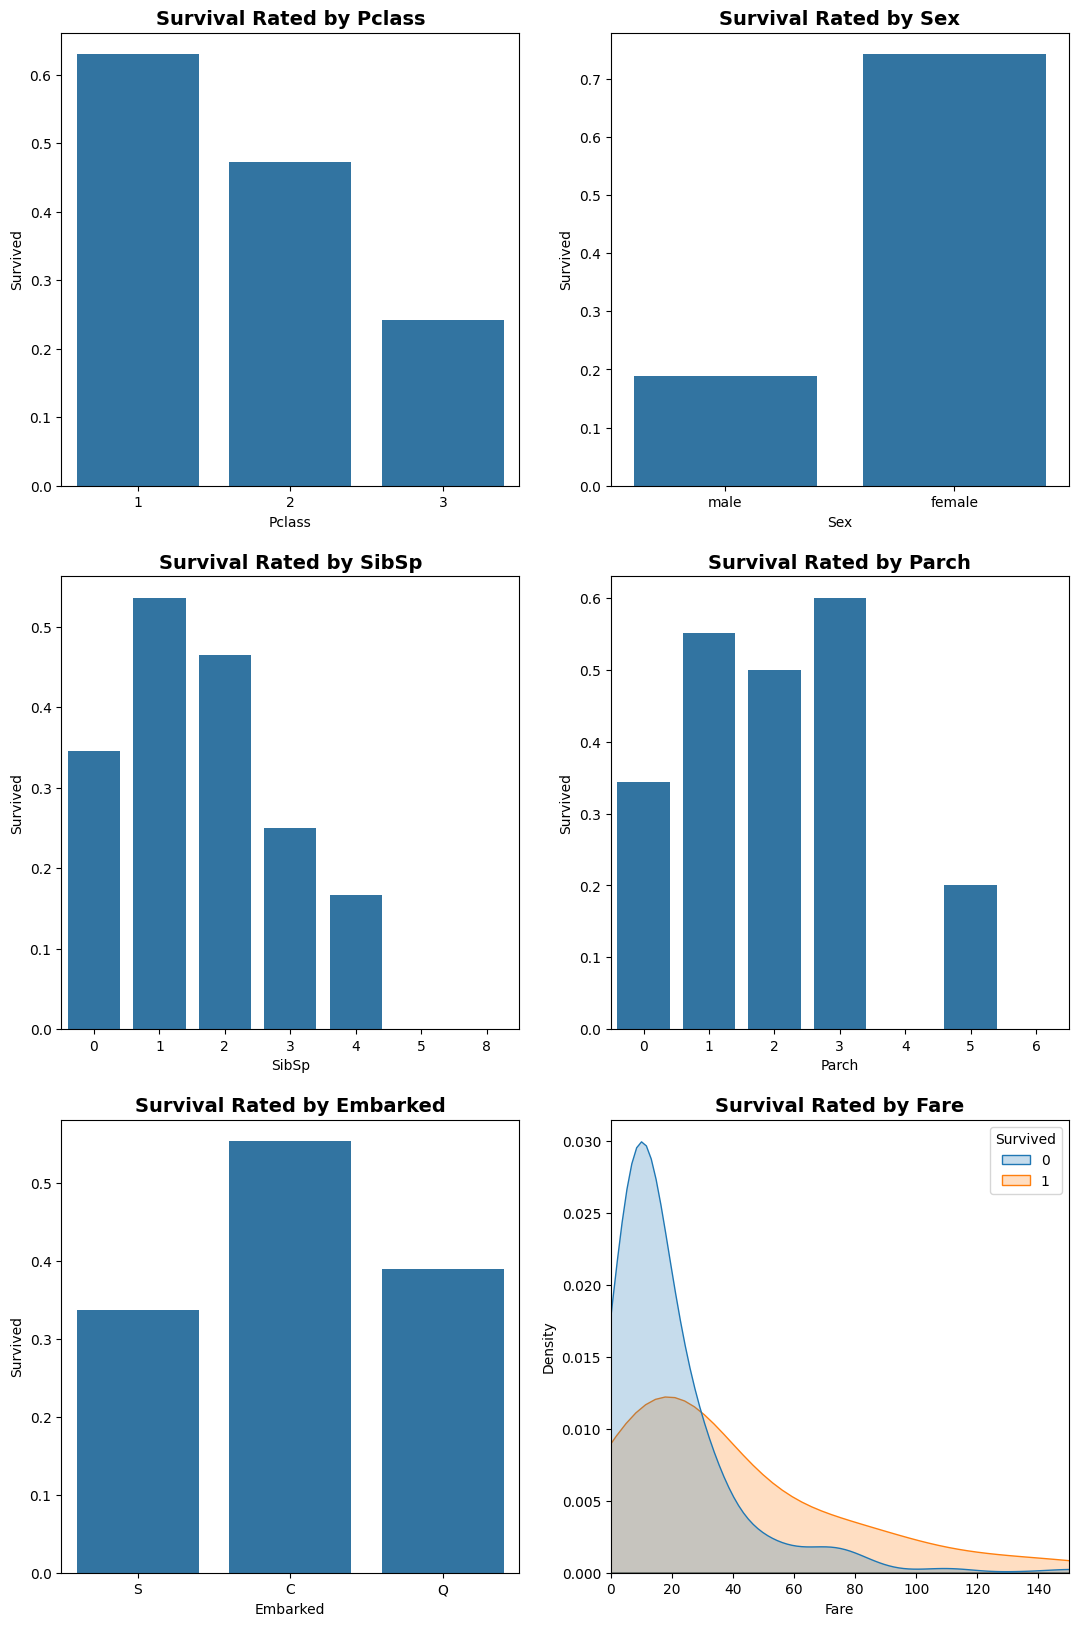

In [41]:
fig,axes=plt.subplots(3,2,figsize=(13,20))
axes=axes.flatten()
bar_visualized_columns=['Pclass','Sex','SibSp','Parch','Embarked']
for i in range(len(bar_visualized_columns)):
    sns.barplot(x=bar_visualized_columns[i],ax=axes[i],y='Survived',data=train_df,errorbar=None)
    axes[i].set_title(f'Survival Rated by {bar_visualized_columns[i]}',fontsize=14,fontweight='bold')
    
sns.kdeplot(data=train_df, x='Fare', hue='Survived', fill=True,
            common_norm=False, ax=axes[5])
axes[5].set_title('Survival Rated by Fare', fontsize=14, fontweight='bold')
axes[5].set_xlim(0, 150)

## 3. Data cleaning and Features Engineering
**Strategy:**
* **Drop noise:** `Cabin` is >77% empty. `PassengerId`, `Name`, `Ticket` are identified strings for passengers with no mathmetical value for MLP.
* **Prevent Data Leakage:** Combine Train and Test to ensure identical structure processing.

### 3.1. Combine Train and Test

In [43]:
n_train=len(train_df)
n_train

891

In [61]:
combined_df=pd.concat([train_df.drop(columns=['Survived']),test_df],axis=0)
combined_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


### 3.2. Drop unnecessary columns

In [62]:
columns_to_drop=['PassengerId','Name','Ticket','Cabin']
combined_df.drop(columns=columns_to_drop,inplace=True)
combined_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S
414,1,female,39.0,0,0,108.9000,C
415,3,male,38.5,0,0,7.2500,S
416,3,male,NaN,0,0,8.0500,S


### 3.3. Filling missing values

**Filling missing values in `Age` by median of column `Age` in Train dataset**

In [63]:
combined_df['Age']=combined_df['Age'].fillna(train_df['Age'].median())

**Filling missing values in `Embarked` by mode of column `Embarked` in Train dataset**

In [64]:
combined_df['Embarked']=combined_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [65]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   object 
 2   Age       1309 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1308 non-null   float64
 6   Embarked  1309 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 81.8+ KB


### 3.4. Family Size & Binning
As seen at the bar plot of `SibSp` and `Parch`, we realize that the shape of them is the same. Going alone has low surival rate, going with 1 to 3 people has highest suvival rates and exceeding 4 people causes the death rate grow up.

Instead of requiring neuron network to learn to separate columns, we will combine them in 1 column `FamilySize`=`SibSp`+`Parch`+1. After that, we will bining this colomn in 3 types: `IsAlone`, `SmallFamily` (having 2 to 4 people) and `LargeFamily` (over 4 people)

**Create `FamilySize`**

In [66]:
combined_df['FamilySize']=combined_df['SibSp']+combined_df['Parch']+1

**Create `FamilyType`**

In [67]:
def categorize_family(size):
    if size<2: return 'Alone'
    elif size<=4: return 'Small'
    else: 'Large'
    
combined_df['FamilyType']=combined_df['FamilySize'].apply(categorize_family)

**Drop `Sibsp` and `Parch`**

In [68]:
combined_df.drop(columns=['SibSp','Parch'],inplace=True)

In [69]:
combined_df

,Pclass,Sex,Age,Fare,Embarked,FamilySize,FamilyType
0,3,male,22.0,7.2500,S,2,Small
1,1,female,38.0,71.2833,C,2,Small
2,3,female,26.0,7.9250,S,1,Alone
3,1,female,35.0,53.1000,S,2,Small
4,3,male,35.0,8.0500,S,1,Alone
...,...,...,...,...,...,...,...
413,3,male,28.0,8.0500,S,1,Alone
414,1,female,39.0,108.9000,C,1,Alone
415,3,male,38.5,7.2500,S,1,Alone
416,3,male,28.0,8.0500,S,1,Alone


### 3.5. Encoding and Scaling

**One-hot encoding**

In [70]:
cols_encoded=['Pclass','Sex','Embarked','FamilyType']
combined_df=pd.get_dummies(combined_df,columns=cols_encoded,drop_first=True)
combined_df=combined_df.astype(float)
combined_df

,Age,Fare,FamilySize,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,FamilyType_Small
0,22.0,7.2500,2.0,0.0,1.0,1.0,0.0,1.0,1.0
1,38.0,71.2833,2.0,0.0,0.0,0.0,0.0,0.0,1.0
2,26.0,7.9250,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,35.0,53.1000,2.0,0.0,0.0,0.0,0.0,1.0,1.0
4,35.0,8.0500,1.0,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
413,28.0,8.0500,1.0,0.0,1.0,1.0,0.0,1.0,0.0
414,39.0,108.9000,1.0,0.0,0.0,0.0,0.0,0.0,0.0
415,38.5,7.2500,1.0,0.0,1.0,1.0,0.0,1.0,0.0
416,28.0,8.0500,1.0,0.0,1.0,1.0,0.0,1.0,0.0


**Normalizing `Fare`**

Look at the plot of `Fare`, we can see that it has long tail which means that a large of passengers have ticket values between 10 to 40, a few number of passengers have high ticket values (such as 512). Those otliers can make network skip another important features. So that we have to normalize it.

In [71]:
combined_df['Fare']=np.log1p(combined_df['Fare'])

**Split back train/test dataset**

In [72]:
train=combined_df[:n_train]
test=combined_df[n_train:]
train_target=train_df['Survived']

In [73]:
train

,Age,Fare,FamilySize,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,FamilyType_Small
0,22.0,2.110213,2.0,0.0,1.0,1.0,0.0,1.0,1.0
1,38.0,4.280593,2.0,0.0,0.0,0.0,0.0,0.0,1.0
2,26.0,2.188856,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,35.0,3.990834,2.0,0.0,0.0,0.0,0.0,1.0,1.0
4,35.0,2.202765,1.0,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
886,27.0,2.639057,1.0,1.0,0.0,1.0,0.0,1.0,0.0
887,19.0,3.433987,1.0,0.0,0.0,0.0,0.0,1.0,0.0
888,28.0,3.196630,4.0,0.0,1.0,0.0,0.0,1.0,1.0
889,26.0,3.433987,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [76]:
train_target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

**Scaling data**

In [77]:
scaler=StandardScaler()
train_scaled=scaler.fit_transform(train)
test_scaled=scaler.transform(test)
train_target_scaled=train_target.values.reshape(-1,1)

In [79]:
train_target_scaled

array([[0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
    

In [78]:
train_scaled

array([[-0.56573646, -0.87974057,  0.05915988, ..., -0.30756234,
         0.61583843,  1.4322604 ],
       [ 0.66386103,  1.36121993,  0.05915988, ..., -0.30756234,
        -1.62380254,  1.4322604 ],
       [-0.25833709, -0.79853997, -0.56097483, ..., -0.30756234,
         0.61583843, -0.69819706],
       ...,
       [-0.1046374 ,  0.24200664,  1.29942929, ..., -0.30756234,
         0.61583843,  1.4322604 ],
       [-0.25833709,  0.48708246, -0.56097483, ..., -0.30756234,
        -1.62380254, -0.69819706],
       [ 0.20276197, -0.81898658, -0.56097483, ...,  3.25137334,
        -1.62380254, -0.69819706]], shape=(891, 9))

In [81]:
test_scaled

array([[ 0.39488658, -0.80968284, -0.56097483, ...,  3.25137334,
        -1.62380254, -0.69819706],
       [ 1.35550962, -0.91151292,  0.05915988, ..., -0.30756234,
         0.61583843,  1.4322604 ],
       [ 2.50825727, -0.61246078, -0.56097483, ...,  3.25137334,
        -1.62380254, -0.69819706],
       ...,
       [ 0.70228595, -0.87974057, -0.56097483, ..., -0.30756234,
         0.61583843, -0.69819706],
       [-0.1046374 , -0.78417924, -0.56097483, ..., -0.30756234,
         0.61583843, -0.69819706],
       [-0.1046374 ,  0.19484336,  0.67929458, ..., -0.30756234,
        -1.62380254,  1.4322604 ]], shape=(418, 9))

### 3.6. Train/Validation/Test Split

In [82]:
X_train,X_temp,y_train,y_temp=train_test_split(train_scaled,train_target_scaled,test_size=0.3,
                                               random_state=42,shuffle=True,stratify=train_target_scaled)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,
                                               random_state=42,shuffle=True,stratify=y_temp)

In [ ]:
test_id_kaggle=test_df['PassengerId'].values

## 4. Save data

In [84]:
np.save('../data/processed/X_train.npy',X_train)
np.save('../data/processed/y_train.npy',y_train)
np.save('../data/processed/X_val.npy',X_val)
np.save('../data/processed/y_val.npy',y_val)
np.save('../data/processed/X_test.npy',X_test)
np.save('../data/processed/y_test.npy',y_test)

np.save('../data/processed/test_kaggle.npy',test_scaled)
np.save('../data/processed/test_id_kaggle.npy',test_id_kaggle)